# Example 6.6 Cliff Walking
Consider the gridworld shown below. 
This is a standard undiscounted, episodic task, with start and goal states, and the usual actions causing movement up, down, right, and left.
Reward is −1 on all transitions except those into the the region marked “The Cliff.” 
Stepping into this region incurs a reward of −100 and sends the agent instantly back to the start.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parameters
h = 7
w = 10
states = [(x, y) for x in range(w) for y in range(h)]
cliff = [(x, 0) for x in range(1, w - 1)]
epsilon = 0.1
alpha = 0.5
actions = [(1, 0), (0, 1), (-1, 0), (0, -1)]
start = (0, 0)
goal = (w - 1, 0)
T = 5000

In [3]:
def showPath(path):
    # Create a grid to visualize the path
    grid = np.zeros((h, w), dtype=int)
    
    # Mark the path
    for i, state in enumerate(path):
        x, y = state
        grid[y, x] = i
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    ax.grid(True)
    
    # Draw path on grid
    for i, state in enumerate(path):
        x, y = state
        ax.text(x, y, str(i), ha='center', va='center', fontsize=10)
    
    # Mark start and goal
    ax.plot(start[0], start[1], 'go', markersize=15, label='Start')
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal')

    # Mark cliff
    xs = [grid[0] for grid in cliff]
    ys = [grid[1] for grid in cliff]
    ax.plot(xs, ys, 'y^', markersize=15, label='Cliff' )
    
    # Draw line connecting the path
    xs = [state[0] for state in path]
    ys = [state[1] for state in path]
    ax.plot(xs, ys, 'b-', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Learned Path')
    ax.legend()
    plt.show()

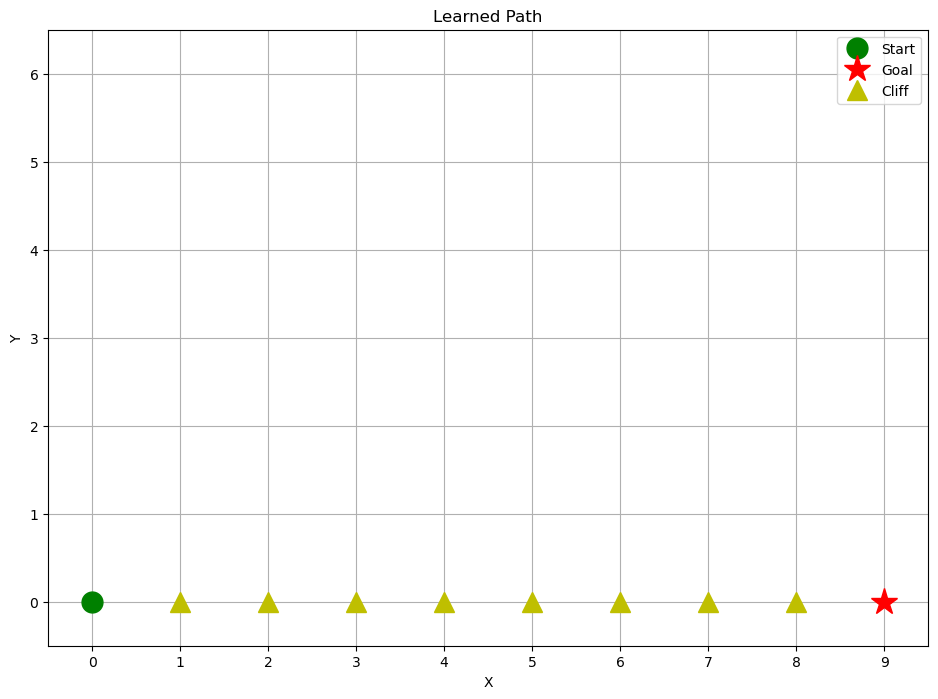

In [4]:
showPath([])

In [5]:
def decideAction(Q, state, epsilon):
    sample = np.random.random()
    if sample < epsilon:
        # random
        return actions[np.random.choice([num for num in range(len(actions))])]
    else:
        # greedy
        maxQ = -1e6
        for action in actions:
            if Q[state][action] > maxQ:
                maxQ = Q[state][action]
                optimalAction = action
        return optimalAction

In [6]:
def takeAction(state, action):
    x, y = state
    dx, dy = action
    nx = x + dx
    nx = min(max(nx, 0), w - 1)
    ny = y + dy
    ny = min(max(ny, 0), h - 1)
    if (nx, ny) in cliff:
        return -100, (0, 0)
    else:
        return -1, (nx, ny)

## Sarsa

In [7]:
Q = {state : {action : 0 for action in actions} for state in states}
for t in range(T):
    currState = start
    currAction = decideAction(Q, currState, epsilon / (t + 1))
    while currState != goal:
        reward, nextState = takeAction(currState, currAction)
        nextAction = decideAction(Q, nextState, epsilon / (t + 1))
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + Q[nextState][nextAction] - Q[currState][currAction])
        currState = nextState
        currAction = nextAction

In [8]:
policy = {}
for state in states:
    maxQ = -1e6
    optimalAction = None
    for action in actions:
        if Q[state][action] > maxQ:
            maxQ = Q[state][action]
            optimalAction = action
    policy[state] = optimalAction

In [9]:
state = start
count = 0
G = 0
path = []
while state != goal:
    path.append(state)
    action = policy[state]
    reward, state = takeAction(state, action)
    count += 1
    G += reward
path.append(goal)
print(count, G)

13 -13


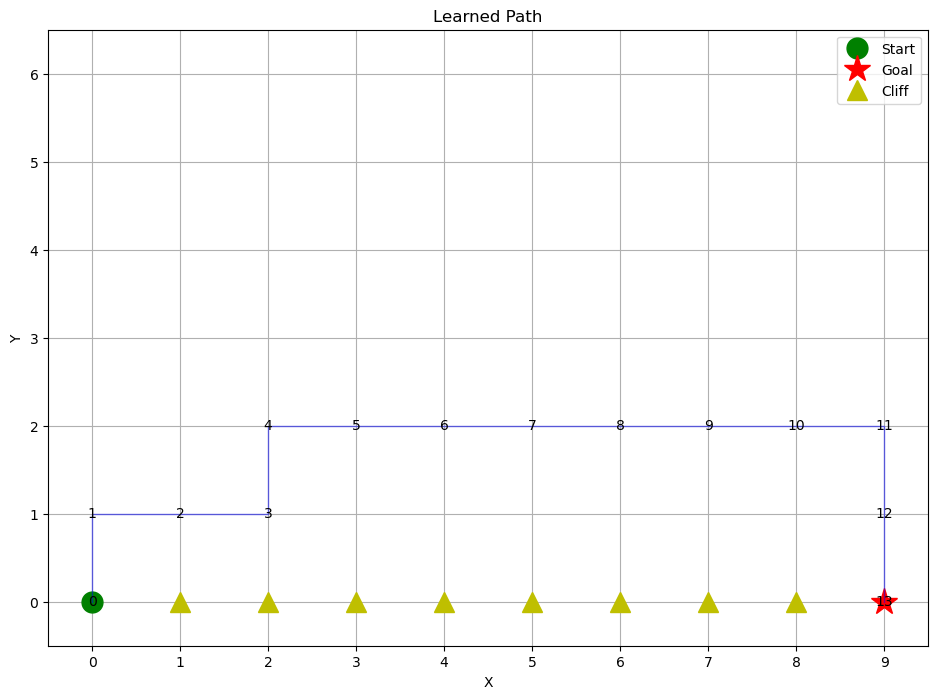

In [10]:
showPath(path)

## Q-learning

In [11]:
Q = {state : {action : 0 for action in actions} for state in states}
for t in range(T):
    currState = start
    while currState != goal:
        currAction = decideAction(Q, currState, epsilon / (t + 1))
        reward, nextState = takeAction(currState, currAction)
        optimalAction = decideAction(Q, nextState, -1)
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + Q[nextState][optimalAction] - Q[currState][currAction])
        currState = nextState

In [12]:
policy = {}
for state in states:
    maxQ = -1e6
    optimalAction = None
    for action in actions:
        if Q[state][action] > maxQ:
            maxQ = Q[state][action]
            optimalAction = action
    policy[state] = optimalAction

In [13]:
state = start
count = 0
G = 0
path = []
while state != goal:
    path.append(state)
    action = policy[state]
    reward, state = takeAction(state, action)
    count += 1
    G += reward
path.append(goal)
print(count, G)

11 -11


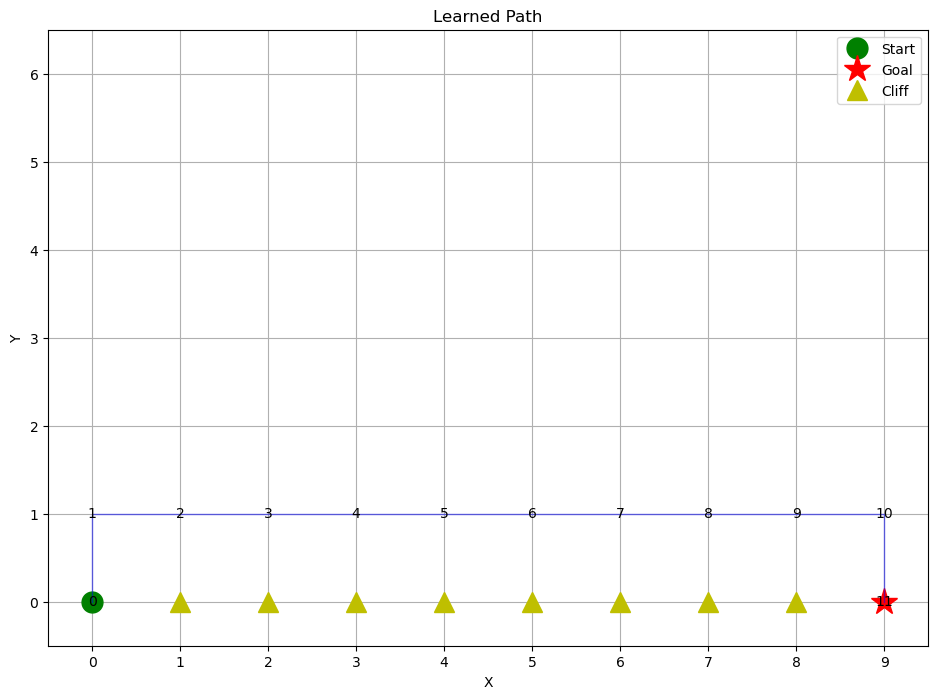

In [14]:
showPath(path)

## Expected Sarsa

In [15]:
Q = {state : {action : 0 for action in actions} for state in states}
for t in range(T):
    currState = start
    while currState != goal:
        currAction = decideAction(Q, currState, epsilon / (t + 1))
        reward, nextState = takeAction(currState, currAction)
        optimalAction = decideAction(Q, nextState, -1)
        expectedValue = 0
        for action in actions:
            if action != optimalAction:
                expectedValue += epsilon / (t + 1) / len(actions) * Q[nextState][action]
            else:
                expectedValue += (1 - epsilon / (t + 1) + epsilon / (t + 1) / len(actions)) * Q[nextState][action]
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + expectedValue - Q[currState][currAction])
        currState = nextState

In [16]:
policy = {}
for state in states:
    maxQ = -1e6
    optimalAction = None
    for action in actions:
        if Q[state][action] > maxQ:
            maxQ = Q[state][action]
            optimalAction = action
    policy[state] = optimalAction

In [17]:
state = start
count = 0
G = 0
path = []
while state != goal:
    path.append(state)
    action = policy[state]
    reward, state = takeAction(state, action)
    count += 1
    G += reward
path.append(goal)
print(count, G)

11 -11


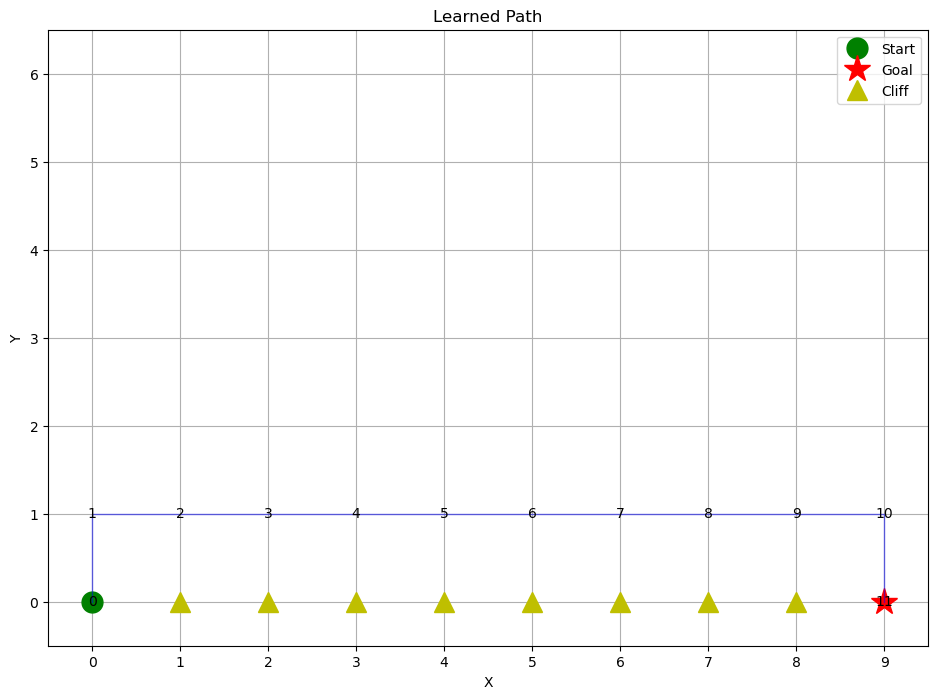

In [18]:
showPath(path)